# Task 8.2D: Problem Solving Task

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
import joblib

## Data Preprocessing

In [33]:
df = pd.read_csv('melbourne_housing.csv')

df.head()

,Suburb,Sold Price (AUD),Property Type,Bedrooms,Bathrooms,Car Spaces,Land Size (m2),Floor Area (m2),Sale Date,Travel Time to CBD (min),Has Garden
0,Hawthorn,928000,Unit,2,1,1,NaN,NaN,09/05/2026,25,1
1,Hawthorn,712500,Unit,2,1,1,NaN,90.0,09/05/2026,20,0
2,Hawthorn,687000,Unit,2,2,1,NaN,NaN,09/05/2026,20,0
3,Hawthorn,390000,Unit,1,1,1,NaN,NaN,08/05/2026,21,0
4,Hawthorn,735000,Unit,2,2,1,NaN,93.0,07/05/2026,23,0


In [34]:
# Check shape 
print("Shape:", df.shape)

# Check column names and data types
print("\nInfo:")
df.info()

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (150, 11)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Suburb                    150 non-null    object 
 1   Sold Price (AUD)          150 non-null    int64  
 2   Property Type             150 non-null    object 
 3   Bedrooms                  150 non-null    int64  
 4   Bathrooms                 150 non-null    int64  
 5   Car Spaces                150 non-null    int64  
 6   Land Size (m2)            55 non-null     float64
 7   Floor Area (m2)           11 non-null     float64
 8   Sale Date                 150 non-null    object 
 9   Travel Time to CBD (min)  150 non-null    int64  
 10  Has Garden                150 non-null    int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 13.0+ KB

Missing Values:
Suburb                        0
Sold Price (AUD)              0
Property Typ

In [35]:
# Drop Floor Area column (too many missing values)
df = df.drop(columns=['Floor Area (m2)'])

# Fill missing Land Size with 0 (these are units with no land)
df['Land Size (m2)'] = df['Land Size (m2)'].fillna(0)

print("Missing values after fix:")
print(df.isnull().sum())

Missing values after fix:
Suburb                      0
Sold Price (AUD)            0
Property Type               0
Bedrooms                    0
Bathrooms                   0
Car Spaces                  0
Land Size (m2)              0
Sale Date                   0
Travel Time to CBD (min)    0
Has Garden                  0
dtype: int64


In [36]:
# Convert Sale Date to datetime format
df['Sale Date'] = pd.to_datetime(df['Sale Date'], format='%d/%m/%Y')

df['Sale Year'] = df['Sale Date'].dt.year
df['Sale Month'] = df['Sale Date'].dt.month

# Drop original Sale Date column (no longer needed)
df = df.drop(columns=['Sale Date'])

print("New columns added:")
print(df.head())

New columns added:
     Suburb  Sold Price (AUD) Property Type  Bedrooms  Bathrooms  Car Spaces  \
0  Hawthorn            928000          Unit         2          1           1   
1  Hawthorn            712500          Unit         2          1           1   
2  Hawthorn            687000          Unit         2          2           1   
3  Hawthorn            390000          Unit         1          1           1   
4  Hawthorn            735000          Unit         2          2           1   

   Land Size (m2)  Travel Time to CBD (min)  Has Garden  Sale Year  Sale Month  
0             0.0                        25           1       2026           5  
1             0.0                        20           0       2026           5  
2             0.0                        20           0       2026           5  
3             0.0                        21           0       2026           5  
4             0.0                        23           0       2026           5  


In [37]:
# One-hot encode Suburb and Property Type
df = pd.get_dummies(df, columns=['Suburb', 'Property Type'])

print("Shape after encoding:", df.shape)
print("Columns:", df.columns.tolist())

Shape after encoding: (150, 14)
Columns: ['Sold Price (AUD)', 'Bedrooms', 'Bathrooms', 'Car Spaces', 'Land Size (m2)', 'Travel Time to CBD (min)', 'Has Garden', 'Sale Year', 'Sale Month', 'Suburb_Burwood', 'Suburb_Hawthorn', 'Suburb_Ringwood', 'Property Type_House', 'Property Type_Unit']


In [38]:
# Columns to scale
scale_cols = ['Bedrooms', 'Bathrooms', 'Car Spaces', 
              'Land Size (m2)', 'Travel Time to CBD (min)',
              'Sale Year', 'Sale Month']

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print("Normalisation: ")
print(df.head())

Normalisation: 
   Sold Price (AUD)  Bedrooms  Bathrooms  Car Spaces  Land Size (m2)  \
0            928000 -0.435319  -0.802706   -0.587684       -0.679444   
1            712500 -0.435319  -0.802706   -0.587684       -0.679444   
2            687000 -0.435319   0.942306   -0.587684       -0.679444   
3            390000 -1.329810  -0.802706   -0.587684       -0.679444   
4            735000 -0.435319   0.942306   -0.587684       -0.679444   

   Travel Time to CBD (min)  Has Garden  Sale Year  Sale Month  \
0                 -0.927965           1   0.562978    0.144841   
1                 -1.741969           0   0.562978    0.144841   
2                 -1.741969           0   0.562978    0.144841   
3                 -1.579168           0   0.562978    0.144841   
4                 -1.253566           0   0.562978    0.144841   

   Suburb_Burwood  Suburb_Hawthorn  Suburb_Ringwood  Property Type_House  \
0           False             True            False                False   
1 

In [39]:
# Convert True/False to 1/0
df = df.astype({
    'Suburb_Burwood': int,
    'Suburb_Hawthorn': int,
    'Suburb_Ringwood': int,
    'Property Type_House': int,
    'Property Type_Unit': int
})

print(df.head())

   Sold Price (AUD)  Bedrooms  Bathrooms  Car Spaces  Land Size (m2)  \
0            928000 -0.435319  -0.802706   -0.587684       -0.679444   
1            712500 -0.435319  -0.802706   -0.587684       -0.679444   
2            687000 -0.435319   0.942306   -0.587684       -0.679444   
3            390000 -1.329810  -0.802706   -0.587684       -0.679444   
4            735000 -0.435319   0.942306   -0.587684       -0.679444   

   Travel Time to CBD (min)  Has Garden  Sale Year  Sale Month  \
0                 -0.927965           1   0.562978    0.144841   
1                 -1.741969           0   0.562978    0.144841   
2                 -1.741969           0   0.562978    0.144841   
3                 -1.579168           0   0.562978    0.144841   
4                 -1.253566           0   0.562978    0.144841   

   Suburb_Burwood  Suburb_Hawthorn  Suburb_Ringwood  Property Type_House  \
0               0                1                0                    0   
1               0 

In [40]:
# Save cleaned dataset
df.to_csv('melbourne_housing_clean.csv', index=False)
print("Final shape:", df.shape)
print("Columns:", df.columns.tolist())

Final shape: (150, 14)
Columns: ['Sold Price (AUD)', 'Bedrooms', 'Bathrooms', 'Car Spaces', 'Land Size (m2)', 'Travel Time to CBD (min)', 'Has Garden', 'Sale Year', 'Sale Month', 'Suburb_Burwood', 'Suburb_Hawthorn', 'Suburb_Ringwood', 'Property Type_House', 'Property Type_Unit']


## Data Analysis

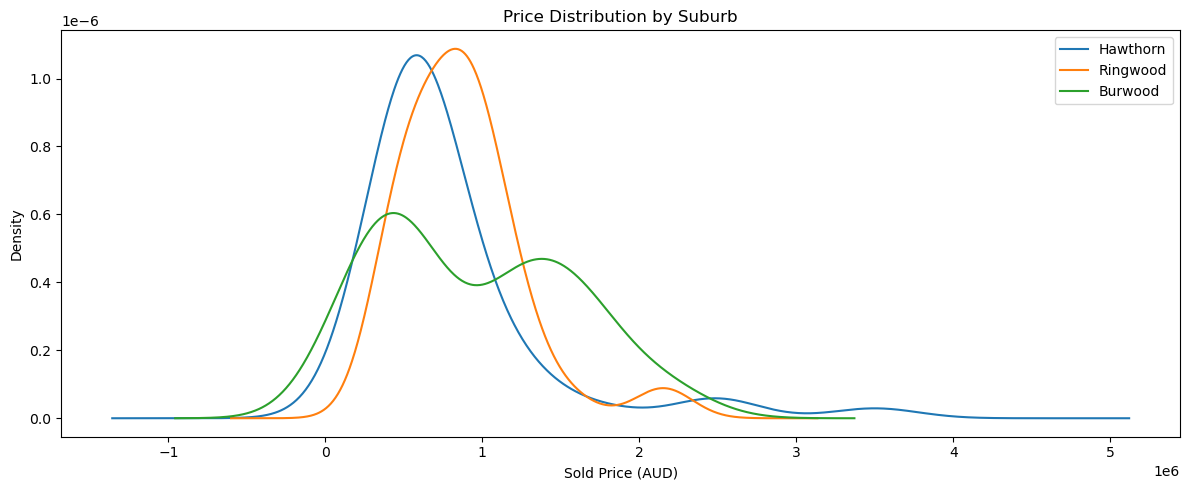

In [41]:
plt.figure(figsize=(12, 5))
for suburb in df_viz['Suburb'].unique():
    subset = df_viz[df_viz['Suburb'] == suburb]['Sold Price (AUD)']
    subset.plot(kind='kde', label=suburb)

plt.title('Price Distribution by Suburb')
plt.xlabel('Sold Price (AUD)')
plt.legend()
plt.tight_layout()
plt.show()

The three suburbs have different price patterns. Burwood has the highest average sale price, mostly because it has larger houses with bigger land. Hawthorn has the biggest gap between its cheapest and most expensive properties, as it has both affordable units and very expensive houses. Ringwood has the most similar prices across its properties, meaning it is the most stable and predictable suburb of the three.

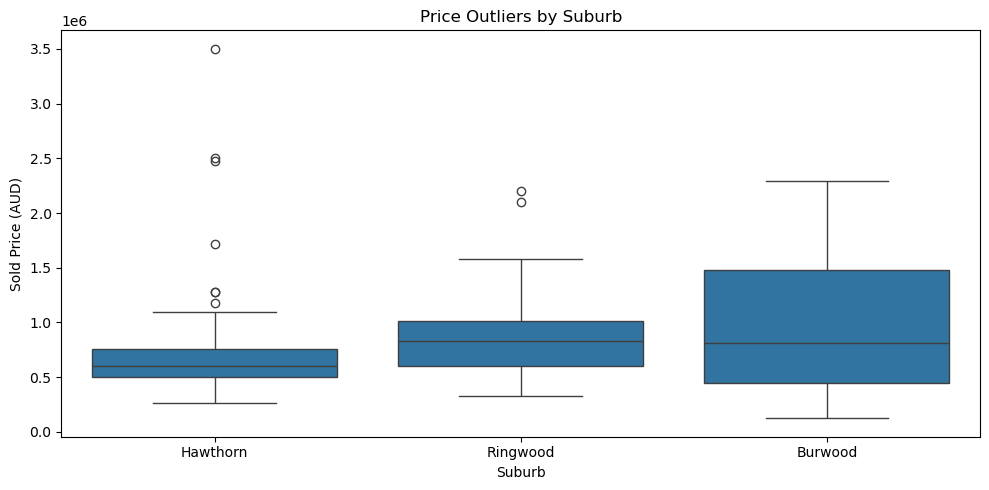

In [42]:
# Box plot to show outliers
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_viz, x='Suburb', y='Sold Price (AUD)')
plt.title('Price Outliers by Suburb')
plt.tight_layout()
plt.show()

Some properties sold for much higher prices than the rest, and most of these were houses. Hawthorn had the most of these high-priced properties, which makes sense as it is an inner-city suburb. Ringwood and Burwood also had a few very expensive houses with large land sizes. 

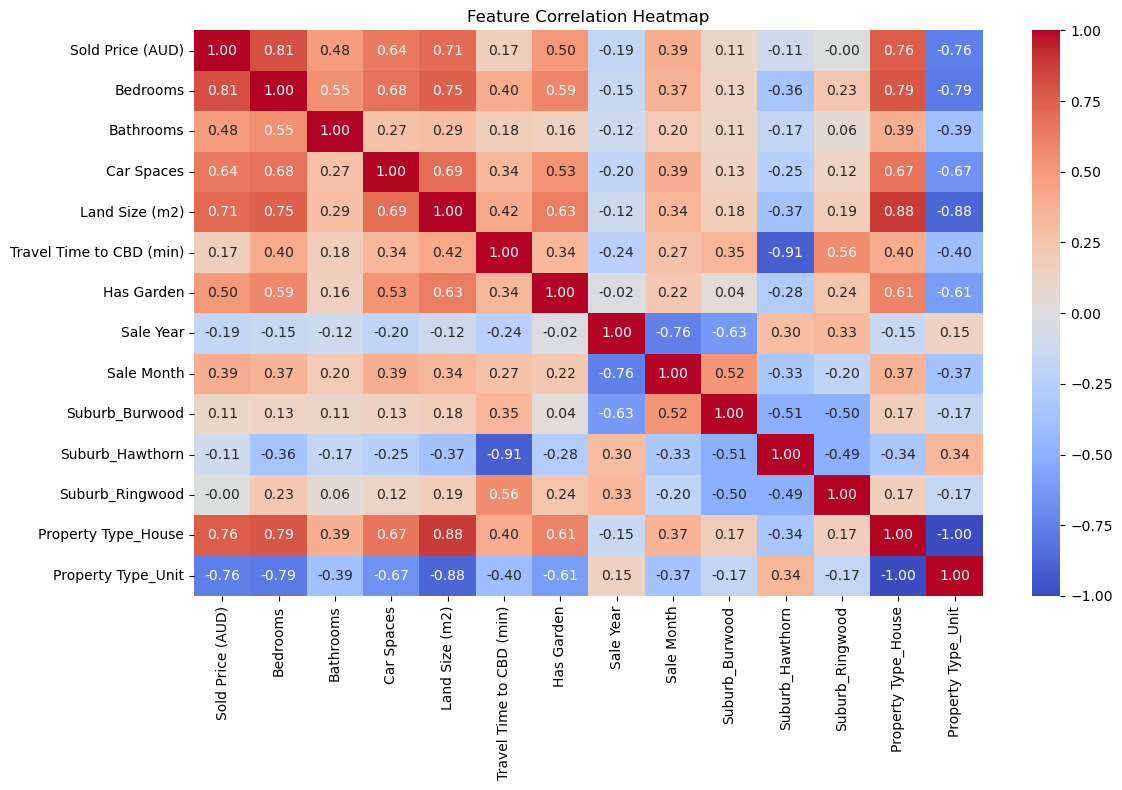

In [43]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

Having more bedrooms was the biggest factor in determining price, with a correlation of 0.808, followed by whether the property is a house at 0.763 and land size at 0.707. This means buyers are mainly paying for size and space. Surprisingly, travel time to the CBD had a very weak correlation of only 0.167, meaning how far the property is from the city centre did not have much impact on price. The suburb itself also showed almost no correlation, which suggests that what a property has is more important than exactly where it is located.

## Model Development

In [44]:
# Features and target
X = df.drop(columns=['Sold Price (AUD)'])
y = df['Sold Price (AUD)']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 13)
Target shape: (150,)


In [45]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# K-Fold setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():
    mae_scores = []
    rmse_scores = []
    r2_scores = []
    
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        mae_scores.append(mean_absolute_error(y_test, y_pred))
        rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
        r2_scores.append(r2_score(y_test, y_pred))
    
    results[name] = {
        'MAE': np.mean(mae_scores),
        'RMSE': np.mean(rmse_scores),
        'R2': np.mean(r2_scores)
    }

print("Model Evaluation Results: ")
for name, metrics in results.items():
    print(f"\n{name}:")
    print(f"  MAE:  ${metrics['MAE']:,.0f}")
    print(f"  RMSE: ${metrics['RMSE']:,.0f}")
    print(f"  R2:   {metrics['R2']:.3f}")

Model Evaluation Results: 

Linear Regression:
  MAE:  $202,197
  RMSE: $294,353
  R2:   0.676

Random Forest:
  MAE:  $164,479
  RMSE: $242,762
  R2:   0.773

Gradient Boosting:
  MAE:  $160,699
  RMSE: $238,203
  R2:   0.781


Three regression models were trained and evaluated using five-fold cross validation to predict Melbourne housing prices. Gradient Boosting performed the best overall, with the lowest average error of AUD160,699 and an R² score of 0.781, meaning it could explain around 78% of the variation in house prices. Random Forest came in second with a similar average error of AUD164,479 and an R² of 0.773, showing only a slight difference from Gradient Boosting. Linear Regression was the weakest of the three, with a higher average error of AUD202,197 and an R² of 0.676, suggesting that the relationship between property features and price is not entirely linear. Overall, all three models performed reasonably well given the relatively small dataset of 150 properties, and the results suggest that tree-based models such as Random Forest and Gradient Boosting are better suited for predicting housing prices than a simple linear approach.

## Model Evaluation

In [46]:
# Train Linear Regression on full dataset
lr_model = LinearRegression()
lr_model.fit(X, y)

# Get coefficients
importance_lr = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)

print("Feature Coefficients (Linear Regression): ")
print(importance_lr.round(0))

Feature Coefficients (Linear Regression): 
                     Feature  Coefficient
0                   Bedrooms     275306.0
9            Suburb_Hawthorn     209093.0
11       Property Type_House     145737.0
3             Land Size (m2)      56895.0
7                 Sale Month      45298.0
1                  Bathrooms      43772.0
2                 Car Spaces      31271.0
4   Travel Time to CBD (min)       1168.0
5                 Has Garden        220.0
6                  Sale Year     -18628.0
8             Suburb_Burwood     -78741.0
10           Suburb_Ringwood    -130352.0
12        Property Type_Unit    -145737.0


In [47]:
# Train Random Forest on full dataset
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Get feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (Random Forest): ")
print(importance.round(3))

Feature Importance (Random Forest): 
                     Feature  Importance
12        Property Type_Unit       0.230
0                   Bedrooms       0.213
11       Property Type_House       0.150
3             Land Size (m2)       0.144
4   Travel Time to CBD (min)       0.107
7                 Sale Month       0.033
10           Suburb_Ringwood       0.030
1                  Bathrooms       0.026
2                 Car Spaces       0.018
9            Suburb_Hawthorn       0.015
5                 Has Garden       0.012
6                  Sale Year       0.012
8             Suburb_Burwood       0.010


In [48]:
# Train Gradient Boosting on full dataset
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X, y)

# Get feature importance
importance_gb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (Gradient Boosting): ")
print(importance_gb.round(3))

Feature Importance (Gradient Boosting): 
                     Feature  Importance
11       Property Type_House       0.343
0                   Bedrooms       0.185
12        Property Type_Unit       0.121
4   Travel Time to CBD (min)       0.093
3             Land Size (m2)       0.060
9            Suburb_Hawthorn       0.037
1                  Bathrooms       0.036
7                 Sale Month       0.030
10           Suburb_Ringwood       0.028
2                 Car Spaces       0.027
6                  Sale Year       0.021
5                 Has Garden       0.011
8             Suburb_Burwood       0.008


Across all three models, property type and number of bedrooms were consistently the most important features in predicting house prices. In the Random Forest model, whether a property is a unit was the biggest factor, followed closely by the number of bedrooms, meaning buyers pay significantly more for houses with more rooms. Gradient Boosting agreed, placing even more weight on whether a property is a house as its top factor. Linear Regression showed that each extra bedroom adds around AUD275,000 to the predicted price, and properties in Hawthorn tend to be priced around AUD209,000 higher compared to the other suburbs. Land size also played a moderate role across all three models, while features like having a garden, the sale year, and the suburb itself had very little impact on the predicted price. Overall, all three models agree that the size and type of a property matter much more than where it is or when it was sold.

## Model Deployment

In [27]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [28]:
# Save the best model (Gradient Boosting)
joblib.dump(gb_model, 'housing_model.pkl')

# Save the scaler 
joblib.dump(scaler, 'scaler.pkl')

print("Model saved!")

Model saved!


In [52]:
#import streamlit as st
#import joblib
#import numpy as np
#from sklearn.preprocessing import StandardScaler

# Load model and scaler
#model = joblib.load('housing_model.pkl')
#scaler = joblib.load('scaler.pkl')

#st.title('Melbourne Housing Price Predictor')
#st.write('Enter the property details below to get a predicted price')

# Input fields
#suburb = st.selectbox('Suburb', ['Hawthorn', 'Ringwood', 'Burwood'])
#property_type = st.selectbox('Property Type', ['House', 'Unit'])
#bedrooms = st.slider('Bedrooms', 1, 6, 3)
#bathrooms = st.slider('Bathrooms', 1, 4, 2)
#car_spaces = st.slider('Car Spaces', 0, 5, 1)
#land_size = st.number_input('Land Size (m2)', min_value=0, max_value=2000, value=500)
#travel_time = st.slider('Travel Time to CBD (min)', 15, 50, 30)
#has_garden = st.selectbox('Has Garden?', ['Yes', 'No'])
#sale_year = st.selectbox('Sale Year', [2024, 2025, 2026])
#sale_month = st.slider('Sale Month', 1, 12, 6)

# Predict button
#if st.button('Predict Price'):

    # Encode inputs
    #suburb_burwood = 1 if suburb == 'Burwood' else 0
    #suburb_hawthorn = 1 if suburb == 'Hawthorn' else 0
    #suburb_ringwood = 1 if suburb == 'Ringwood' else 0
    #type_house = 1 if property_type == 'House' else 0
    #type_unit = 1 if property_type == 'Unit' else 0
    #garden = 1 if has_garden == 'Yes' else 0

    # Scale numerical features
    #numerical = scaler.transform([[bedrooms, bathrooms, car_spaces,
                                   #land_size, travel_time,
                                   #sale_year, sale_month]])

    # Build input array
    #features = np.array([[
        #numerical[0][0], numerical[0][1], numerical[0][2],
        #numerical[0][3], numerical[0][4], garden,
        #numerical[0][5], numerical[0][6],
        #suburb_burwood, suburb_hawthorn, suburb_ringwood,
        #type_house, type_unit
    #]])

    # Make prediction
    #prediction = model.predict(features)[0]

    #st.success(f'💰 Predicted Price: ${prediction:,.0f}')

## LLM Comparison

In [53]:
# Pick the last fold (30 houses) for LLM testing
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
folds = list(kf.split(X))

# Get last fold test set
_, test_index = folds[4]
X_test_llm = df_viz.iloc[test_index][['Suburb', 'Property Type', 
                                       'Bedrooms', 'Bathrooms', 
                                       'Car Spaces', 'Land Size (m2)',
                                       'Travel Time to CBD (min)', 
                                       'Has Garden']].head(10)
y_test_llm = df_viz.iloc[test_index]['Sold Price (AUD)'].head(10)

print("Houses for LLM Testing: ")
print(X_test_llm.to_string())
print("Real Prices (hidden from LLM): ")
print(y_test_llm.to_string())

Houses for LLM Testing: 
      Suburb Property Type  Bedrooms  Bathrooms  Car Spaces  Land Size (m2)  Travel Time to CBD (min)  Has Garden
1   Hawthorn          Unit         2          1           1             NaN                        20           0
14  Hawthorn          Unit         2          2           1             NaN                        23           0
20  Hawthorn          Unit         2          1           1             NaN                        23           1
21  Hawthorn          Unit         2          1           1             NaN                        23           0
37  Hawthorn          Unit         2          1           1             NaN                        19           0
41  Hawthorn          Unit         1          1           1             NaN                        21           0
48  Hawthorn         House         3          3           1            67.0                        23           0
52  Ringwood         House         2          1           1    

In [54]:
# Real prices
y_real = [712500, 635000, 845000, 645000, 672000, 
          462000, 1275000, 701000, 1015000, 2200000]

# LLM predictions
y_llm = [750000, 820000, 780000, 740000, 760000, 
         580000, 1350000, 680000, 820000, 1250000]

# Calculate metrics
mae_llm = mean_absolute_error(y_real, y_llm)
rmse_llm = np.sqrt(mean_squared_error(y_real, y_llm))
r2_llm = r2_score(y_real, y_llm)

print("LLM Performance: ")
print(f"MAE:  ${mae_llm:,.0f}")
print(f"RMSE: ${rmse_llm:,.0f}")
print(f"R2:   {r2_llm:.3f}")

LLM Performance: 
MAE:  $182,950
RMSE: $318,926
R2:   0.557


| Model | MAE | RMSE | R² | Rank |
|---|---|---|---|---|
| Gradient Boosting | AUD160,699 | AUD238,203 | 0.781 | 1st |
| Random Forest | AUD164,479 | AUD242,762 | 0.773 | 2nd |
| Linear Regression | AUD202,197 | AUD294,353 | 0.676 | 3rd |
| LLM (ChatGPT) | AUD182,950 | AUD318,926 | 0.557 | 4th |

When comparing the large language model against the three regression models, the LLM performed worse overall despite having general real estate knowledge. The LLM achieved a MAE of AUD182,950 and an R² of 0.557, meaning it could only explain around 56% of the variation in house prices. This is notably lower than Gradient Boosting and Random Forest, which achieved R² scores of 0.781 and 0.773 respectively. The LLM struggled most with the highest priced property, predicting AUD1,250,000 against a real price of AUD2,200,000, a difference of $950,000. This suggests that while LLMs have broad knowledge about real estate, they lack the ability to learn specific patterns from the actual data the way trained regression models can. Overall, purpose-built regression models trained on real data are more reliable and accurate for predicting housing prices than using a general purpose large language model.